**Integration**

In [44]:
import pandas as pd

# Load Excell Files
fact = pd.read_excel('FactSales.xlsx')
dim_customer = pd.read_excel('DimCustomer.xlsx')
dim_product = pd.read_excel('DimProduct.xlsx')
dim_shipping = pd.read_excel('DimShipping.xlsx')
dim_date = pd.read_excel('DimDate.xlsx')

df = fact.copy()


if 'Customer ID' not in dim_customer.columns:
    dim_customer.columns = ['Customer ID', 'Customer Name', 'Segment']

# Merge df and dim_customer
cust_subset = dim_customer[['Customer ID', 'Segment']].drop_duplicates(
    'Customer ID'
)
df = df.merge(cust_subset, on='Customer ID', how='left')

# Merge df and dim_product
prod_subset = dim_product[
    ['Product ID', 'Category', 'Sub-Category']
].drop_duplicates('Product ID')
df = df.merge(prod_subset, on='Product ID', how='left')

# Merge df and dim_shipping
shipping_subset = dim_shipping[
    ['Shipping ID', 'Country', 'Region', 'Ship Mode_N']
].drop_duplicates('Shipping ID')
df = df.merge(shipping_subset, on='Shipping ID', how='left')

# Merge df and dim_date
date_subset = dim_date[['Miladi', 'mmonthN', 'MquarterN']].drop_duplicates(
    'Miladi'
)
df = df.merge(
    date_subset, left_on='Order Date', right_on='Miladi', how='left'
).drop(columns=['Miladi'])

print(f'تعداد سطرهای جدول نهایی بعد از ادغام: {len(df)}')
print(f'ابعاد نهایی دیتافریم: {df.shape}')

تعداد سطرهای جدول نهایی بعد از ادغام: 49670
ابعاد نهایی دیتافریم: (49670, 26)


**Feature Engineering**

In [45]:
cat_dummies = pd.get_dummies(df["Category"], prefix="Cat")
df = pd.concat([df, cat_dummies], axis=1)

# aggregate
agg_rules = {
    # constant categoricals
    "Order Priority": "first",
    "Segment": "first",
    "Region": "first",
    "Country": "first",
    "mmonthN": "first",
    "MquarterN": "first",
    "Order Date": "first",
    # numeric
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum",
    "Shipping Cost": "sum",
    "Discount": "mean",
    # ویژگی‌های تنوع سبد
    "Product ID": "count", 
    "Sub-Category": "nunique",
    # target
    "Ship Mode_N": "first",
}

for col in cat_dummies.columns:
    agg_rules[col] = "sum"

df_orders = (
    df.groupby("Order ID", as_index=False)
    .agg(agg_rules)
    .rename(
        columns={
            "Product ID": "Basket_Items_Count",
            "Sub-Category": "Unique_SubCategories",
        }
    )
)

df_orders["Avg_Item_Price"] = df_orders["Sales"] / df_orders["Quantity"]
df_orders["Shipping_Ratio"] = df_orders["Shipping Cost"] / df_orders["Sales"]

In [46]:
df_orders["Day_of_Week"] = df_orders["Order Date"].str.split(",").str[0].str.strip()

df_orders["Is_Weekend"] = df_orders["Day_of_Week"].isin(["Friday", "Saturday", "Sunday"]).astype(int)

df_orders.drop(columns=["Order Date"], inplace=True)


df_orders["Order_Year"] = (
    df_orders["Order ID"].str.split("-").str[1].astype(int)
)

**Train**

In [47]:
train_mask = df_orders["Order_Year"] < 2014
val_mask = df_orders["Order_Year"] == 2014

ignore_cols = ["Order ID", "Ship Mode_N", "Order_Year"]
feature_cols = [c for c in df_orders.columns if c not in ignore_cols]


X_train = df_orders.loc[train_mask, feature_cols].copy()
y_train = df_orders.loc[train_mask, "Ship Mode_N"].copy()

X_val = df_orders.loc[val_mask, feature_cols].copy()
y_val = df_orders.loc[val_mask, "Ship Mode_N"].copy()

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")

# بررسی ابعاد
print(
    f"Train: {len(X_train)} | years: {sorted(df_orders.loc[train_mask, 'Order_Year'].unique())}"
)
print(
    f"Validation: {len(X_val)} | years: {df_orders.loc[val_mask, 'Order_Year'].unique()}"
)

Train: 16502 | years: [2011, 2012, 2013]
Validation: 8531 | years: [2014]


In [48]:
!pip install lightgbm xgboost

In [49]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

X_train['Shipping_To_Sales'] = X_train['Shipping Cost'] / (X_train['Sales'] + 1)
X_val['Shipping_To_Sales'] = X_val['Shipping Cost'] / (X_val['Sales'] + 1)

X_train['Shipping_Per_Qty'] = X_train['Shipping Cost'] / (X_train['Quantity'] + 1)
X_val['Shipping_Per_Qty'] = X_val['Shipping Cost'] / (X_val['Quantity'] + 1)

X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)

X_train_encoded, X_val_encoded = X_train_encoded.align(
    X_val_encoded, join="left", axis=1, fill_value=0
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

In [50]:
custom_weights = {
    0: 4.0,
    1: 1.5,
    2: 2.0,
    3: 1.0,
}

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=6,
        class_weight=custom_weights,
        random_state=42,
        verbose=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss",
    ),
}

y_train_xgb = (
    y_train - 1
    if y_train.min() == 1
    else (
        y_train.astype("category").cat.codes
        if y_train.dtype == "object"
        else y_train
    )
)
y_val_xgb = (
    y_val - 1
    if y_val.min() == 1
    else (
        y_val.astype("category").cat.codes if y_val.dtype == "object" else y_val
    )
)

results = []
trained_models = {}

for name, clf in models.items():
    if name == "Logistic Regression":
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_val_scaled)
    elif name == "XGBoost":
        clf.fit(X_train_encoded, y_train_xgb)
        y_pred_raw = clf.predict(X_val_encoded)
        y_pred = y_pred_raw + 1 if y_train.min() == 1 else y_pred_raw
    else:
        clf.fit(X_train_encoded, y_train)
        y_pred = clf.predict(X_val_encoded)

    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")

    results.append({"Model": name, "Accuracy": acc, "F1-Macro": macro_f1})
    trained_models[name] = clf

leaderboard = (
    pd.DataFrame(results).sort_values(by="F1-Macro", ascending=False).reset_index(drop=True)
)
print(leaderboard)

                 Model  Accuracy  F1-Macro
0             LightGBM  0.644942  0.430758
1        Random Forest  0.606025  0.418537
2              XGBoost  0.680225  0.394884
3  Logistic Regression  0.568984  0.389703
4          Extra Trees  0.546946  0.342699


Top 10 features:
Shipping_Ratio         2188
Shipping_To_Sales      1393
Profit                 1269
Avg_Item_Price         1078
Shipping_Per_Qty       1053
Sales                  1007
Shipping Cost           953
Quantity                722
mmonthN                 700
Order Priority_High     569
dtype: int32


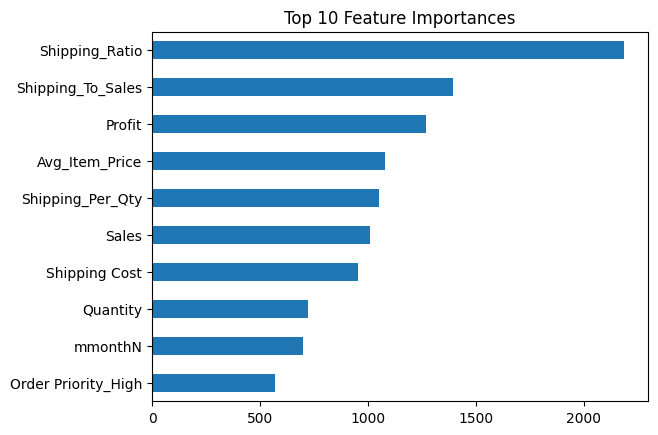

In [51]:
import matplotlib.pyplot as plt

best_model = trained_models["LightGBM"]
importance = pd.Series(
    best_model.feature_importances_, index=X_val_encoded.columns
)
top10_features = importance.sort_values(ascending=False).head(10)

print("Top 10 features:")
print(top10_features)

top10_features.plot(kind="barh", title="Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

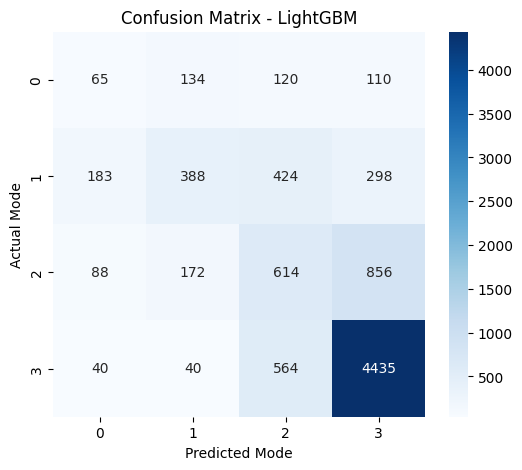

In [52]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_lgbm = best_model.predict(X_val_encoded)
cm = confusion_matrix(y_val, y_pred_lgbm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_,
)
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Mode")
plt.ylabel("Actual Mode")
plt.show()